### Download raw data

In [1]:
import dgeb
from datasets import load_dataset
import numpy as np

/Users/teeratc/Desktop/2026 Spring/CS690U/CS690U-DGEB-project/.venv/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
ecoli_rna_data = load_dataset("tattabio/e_coli_rnas")
mopb_data = load_dataset("tattabio/mopb_clustering")

In [3]:
ecoli_rna_data

DatasetDict({
    train: Dataset({
        features: ['Sequence', 'Label'],
        num_rows: 161
    })
})

In [4]:
mopb_data

DatasetDict({
    train: Dataset({
        features: ['Entry', 'Sequence', 'Label'],
        num_rows: 1300
    })
})

### Embedding data

In [5]:
esm2_model = dgeb.get_model("facebook/esm2_t6_8M_UR50D") # 320-dimensional embeddings for e_coli

Some weights of EsmModel were not initialized from the model checkpoint at facebook/esm2_t6_8M_UR50D and are newly initialized: ['esm.pooler.dense.bias', 'esm.pooler.dense.weight']
You should probably TRAIN this model on a down-stream task to be able to use it for predictions and inference.


In [6]:
ntv2_model = dgeb.get_model("InstaDeepAI/nucleotide-transformer-v2-50m-multi-species") # 512-dimensional embeddings for mopb

In [7]:
def embed_dataset(data, model, dataset_name):
    sequences = data["train"]["Sequence"]
    labels = data["train"]["Label"]
    
    embeddings = []
    for i, seq in enumerate(sequences):
        emb = model.encode([seq])
        embeddings.append(emb[0])
        print(i)

    embeddings = np.array(embeddings)
    print(embeddings.shape)

    np.savez(
        f"Encoded_Data/{dataset_name}_embeddings.npz",
        embeddings=embeddings,
        labels=np.array(labels)
    )
    
    return np.array(embeddings)

In [ ]:
embed_dataset(ecoli_rna_data, esm2_model, "ecoli_rna")

In [ ]:
embed_dataset(mopb_data, ntv2_model, "mopb")

### One-hot encoding data

In [16]:
def onehot_encode_dataset(data, dataset_name, type="NA"):
    sequences = data["train"]["Sequence"]
    labels = data["train"]["Label"]

    if type == "NA":
        alphabet = ["A", "C", "G", "T"]
    elif type == "AA":
        alphabet = ["A", "C", "D", "E", "F", "G", "H", "I", "K", "L", "M", "N", "P", "Q", "R", "S", "T", "V", "W", "Y", "X", "U"]
    else:
        raise ValueError("type must be 'NA' or 'AA'")

    char_to_id = {ch: i for i, ch in enumerate(alphabet)}
    vocab_size = len(alphabet)

    encoded_sequences = []

    for seq in sequences:
        seq = seq.upper()
        one_hot = np.zeros((len(seq), vocab_size))

        for i, ch in enumerate(seq):
            one_hot[i, char_to_id[ch]] = 1

        flat = one_hot.flatten()
        encoded_sequences.append(flat)

    max_len = max(len(vec) for vec in encoded_sequences)

    padded = np.array([
        np.pad(vec, (0, max_len - len(vec)), mode='constant')
        for vec in encoded_sequences
    ])

    print(padded.shape)

    np.savez(
        f"Encoded_Data/{dataset_name}_onehot_encoded.npz",
        embeddings=padded,
        labels=np.array(labels)
    )

    return padded

In [17]:
onehot_encode_dataset(ecoli_rna_data, "ecoli_rna", type="NA")

(161, 400)


array([[0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 1., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 1., 0., ..., 0., 1., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 1., 0.]], shape=(161, 400))

In [18]:
onehot_encode_dataset(mopb_data, "mopb", type="AA")

(1300, 28600)


array([[0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 0., 1., ..., 0., 0., 0.],
       ...,
       [0., 0., 0., ..., 0., 0., 0.],
       [0., 1., 0., ..., 0., 0., 0.],
       [0., 0., 0., ..., 0., 0., 0.]], shape=(1300, 28600))

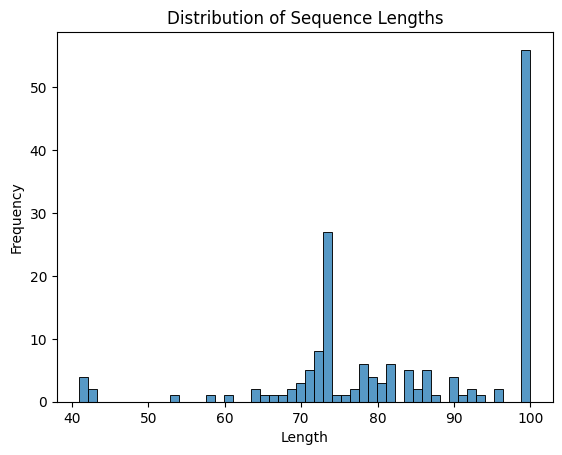

In [22]:
from matplotlib import pyplot as plt
import seaborn as sns
lengths = [len(seq) for seq in ecoli_rna_data["train"]["Sequence"]]
sns.histplot(lengths, bins=50)
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()

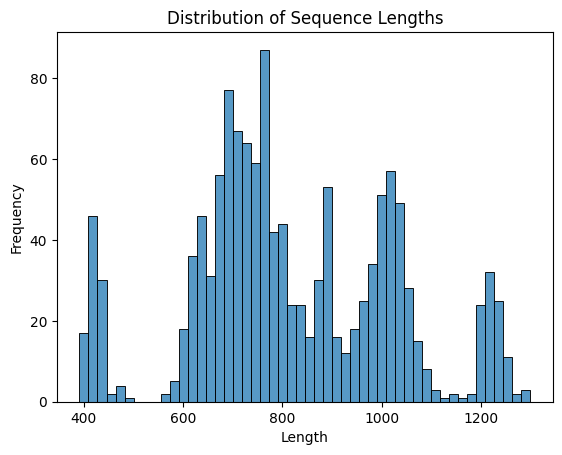

In [23]:
from matplotlib import pyplot as plt
import seaborn as sns
lengths = [len(seq) for seq in mopb_data["train"]["Sequence"]]
sns.histplot(lengths, bins=50)
plt.title("Distribution of Sequence Lengths")
plt.xlabel("Length")
plt.ylabel("Frequency")
plt.show()